In [14]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Set plotting style for clean visuals
plt.style.use('ggplot')

# 1. Load the dataset
df = pd.read_csv('houseprice_data.csv')

# 2. Encode categorical variables
# 'yes' means the price includes interest/agent fees; 'no' is likely the cash price
df['Is Amortized?'] = df['Is Amortized?'].map({'yes': 1, 'no': 0})

# 3. Fill gaps in development scores
df['development'] = df['development'].fillna(df['development'].median())

# 4. Remove extreme outliers (keep 5th to 95th percentile)
q_low, q_hi = df["Price"].quantile([0.05, 0.95])
df_filtered = df[(df["Price"] < q_hi) & (df["Price"] > q_low)].copy()

# 5. One-Hot Encode Barangays
df_encoded = pd.get_dummies(df_filtered, columns=['Barangay'], drop_first=True)

# Define Features: We predict 'Price' using physical attributes + market status
X = df_encoded.drop(['Price', 'Base Price', 'price per lotsqm', 'price per floorsqm'], axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = xgb.XGBRegressor(
    n_estimators=250,
    max_depth=3,          
    learning_rate=0.05,
    reg_lambda=12,        # L2 Regularization to stabilize small data
    subsample=0.8,        # Randomly samples data to prevent overfitting
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Accuracy Metric: Model is off by an average of 29.28%


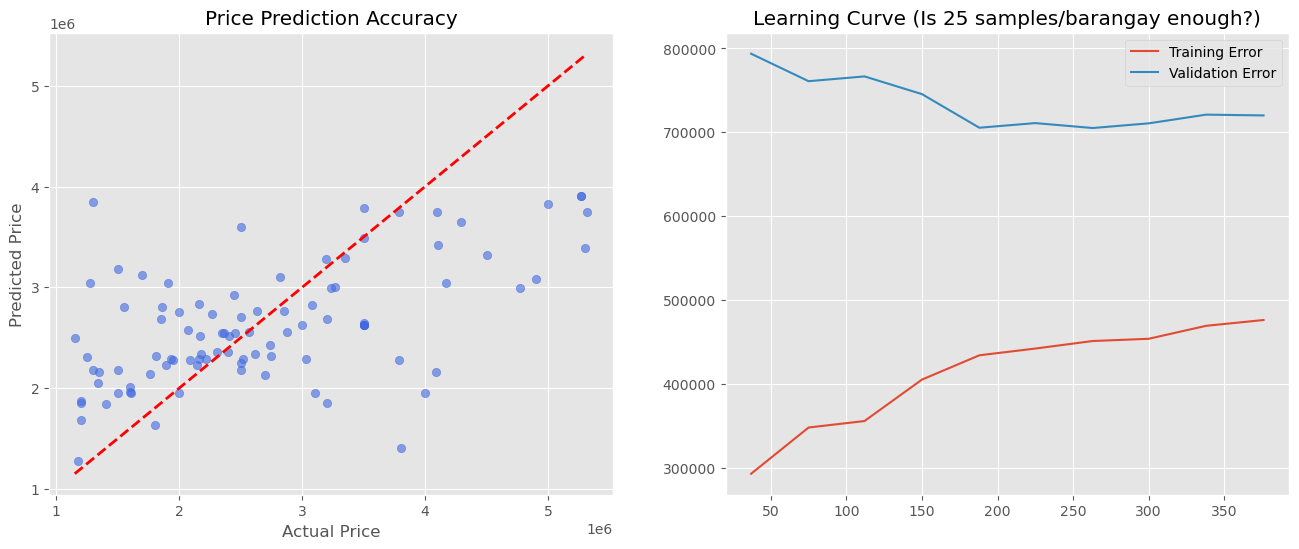

In [16]:
# 1. Calculate MAPE (Mean Absolute Percentage Error)
y_pred = model.predict(X_test)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Accuracy Metric: Model is off by an average of {mape:.2f}%")

# 2. Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Actual vs Predicted
ax1.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Price Prediction Accuracy')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')

# Plot B: Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='neg_mean_absolute_error', train_sizes=np.linspace(0.1, 1.0, 10)
)
ax2.plot(train_sizes, -np.mean(train_scores, axis=1), label='Training Error')
ax2.plot(train_sizes, -np.mean(test_scores, axis=1), label='Validation Error')
ax2.set_title('Learning Curve (Is 25 samples/barangay enough?)')
ax2.legend()

plt.show()

In [17]:
def predict_barangay_future(barangay_name, annual_growth=0.06):
    name = barangay_name.upper()
    subset = df_filtered[df_filtered['Barangay'] == name]
    
    if len(subset) == 0:
        return "Barangay not found."
    
    # Calculate current baseline
    current_avg = subset['Price'].mean()
    dev_status = subset['development'].mean()
    
    # Projections using CAGR formula
    years = [0, 5, 10, 25]
    projections = {yr: current_avg * ((1 + annual_growth) ** yr) for yr in years}
    
    print(f"--- INVESTMENT REPORT: {name} ---")
    print(f"Development Score: {dev_status:.2f}")
    print(f"Current Avg Price: PHP {current_avg:,.2f}")
    print("-" * 40)
    for yr, price in projections.items():
        label = "Current" if yr == 0 else f"In {yr} Years"
        print(f" {label:12}: PHP {price:,.2f}")

# Usage:
predict_barangay_future('JULUGAN')

--- INVESTMENT REPORT: JULUGAN ---
Development Score: 0.55
Current Avg Price: PHP 3,362,959.48
----------------------------------------
 Current     : PHP 3,362,959.48
 In 5 Years  : PHP 4,500,398.39
 In 10 Years : PHP 6,022,548.23
 In 25 Years : PHP 14,433,387.31
